In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal, interpolate
import glob
import gsw
from datetime import timedelta
import warnings
#%matplotlib widget

In [136]:
ds1 = xr.open_dataset('/mnt/scale/crossroad/MOORINGS/FC4/AQD/FC4_Aquadopp_11274-aqd.nc')
ds2 = xr.open_dataset('/mnt/scale/crossroad/MOORINGS/FC4/sbe37_microcat/25915.nc')
ds3 = ds1.copy()

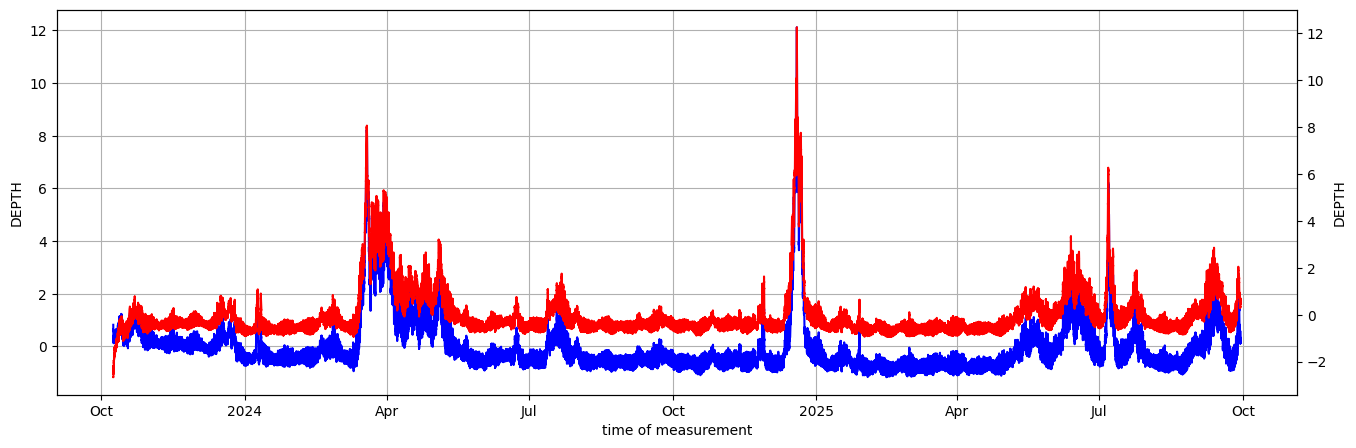

In [164]:
f,ax = plt.subplots(figsize=(16,5))
ax.grid()
A=ds1['DEPTH'].where(ds1['DEPTH_QC']<4)
(A-A.mean()).plot.line('-b',ax=ax)
ax2 = ax.twinx()
B=ds2['DEPTH'].where(ds2['DEPTH_QC']<4)
(B-B.mean()).plot.line('-r',ax=ax2)

In [137]:
A=ds1['DEPTH'].where(ds1['DEPTH_QC']<4)
B=ds2['DEPTH'].where(ds2['DEPTH_QC']<4)
BL = B.dropna('TIME').interp(TIME=A.TIME,method='linear').dropna('TIME')
AL = A.dropna('TIME').interp(TIME=BL.TIME,method='linear').dropna('TIME')

In [138]:
ds = xr.Dataset({'DEPTH':(['TIME','NS'],np.vstack([AL.values,BL.values]).transpose())},{'TIME':AL.TIME.values})
ds

<xarray.Dataset> Size: 2MB
Dimensions:  (TIME: 103893, NS: 2)
Coordinates:
  * TIME     (TIME) datetime64[ns] 831kB 2023-10-08T21:39:59.999997952 ... 20...
Dimensions without coordinates: NS
Data variables:
    DEPTH    (TIME, NS) float64 2MB 3.903e+03 3.897e+03 ... 3.903e+03 3.9e+03

Text(0, 0.5, 'Phase delay estimate (seconds)')

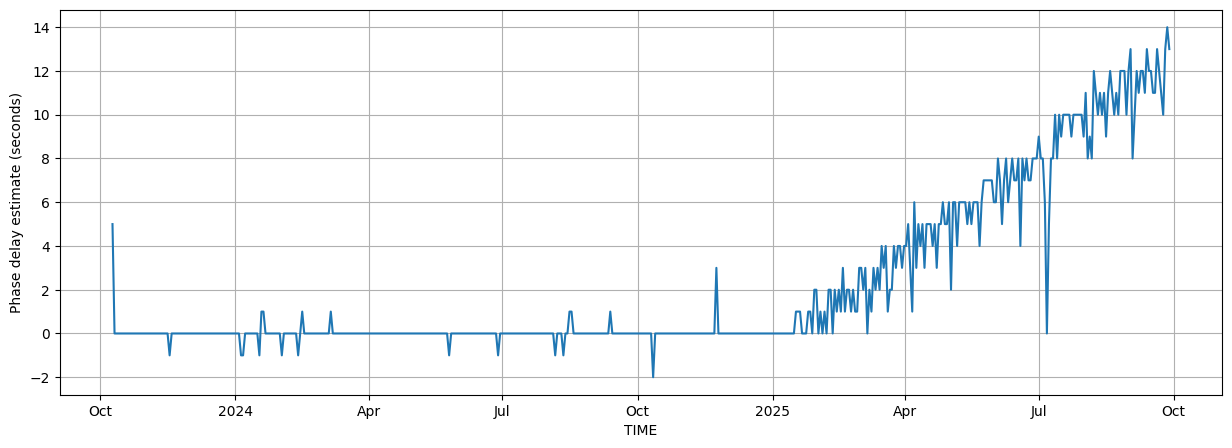

In [166]:
from scipy.ndimage import uniform_filter1d
def mdelayc(x, axis=None):
    # X dimensions : N_GROUP, DATA WITHIN THE GROUP (T,N)
    output = np.zeros([x.shape[0],x.shape[2]])
    for k in range(x.shape[0]):
        x1 = x[k,:,0]
        y1 = x[k,:,1]
        x1 = (x1-np.mean(x1))/np.max(x1)
        y1 = (y1-np.mean(y1))/np.max(y1)
        x1 = uniform_filter1d(x1, 10, mode='nearest')[10:-10]
        y1 = uniform_filter1d(y1, 10, mode='nearest')[10:-10]
        correlation = signal.correlate(x1, y1, mode="full")
        lags = signal.correlation_lags(x1.size, y1.size, mode="full")
        output[k,0] = lags[np.argmax(correlation)]
    return output
    
mdelay = ds['DEPTH'].coarsen(TIME=200, boundary="trim").reduce(mdelayc).isel(NS=0)

f,ax = plt.subplots(1,1,figsize=(15,5))
mdelay.plot(ax=ax)
ax.grid()
ax.set_ylabel('Phase delay estimate (seconds)')

In [284]:
tds=np.zeros(len(ds1['TIME'].values),dtype='timedelta64[s]')
ix = np.argmin(np.abs(ds1['TIME'].values - np.datetime64('2025-02-01')))
tds[ix:] = np.linspace(0,8000,len(tds[ix:]))

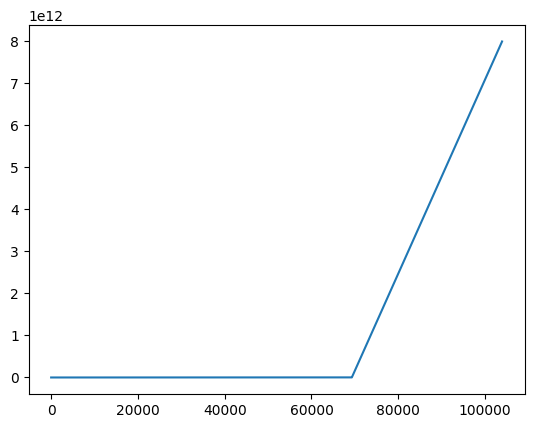

In [285]:
plt.plot(tds.astype('timedelta64[ns]'))

In [286]:
ds3 = ds3.assign_coords(TIME= (ds3['TIME'].values - tds.astype('timedelta64[ns]')))

In [287]:
C = ds3['DEPTH'].where(ds3['DEPTH_QC']<4)
BL = B.dropna('TIME').interp(TIME=C.TIME,method='linear').dropna('TIME')
CL = C.dropna('TIME').interp(TIME=BL.TIME,method='linear').dropna('TIME')

delay : 0  seconds


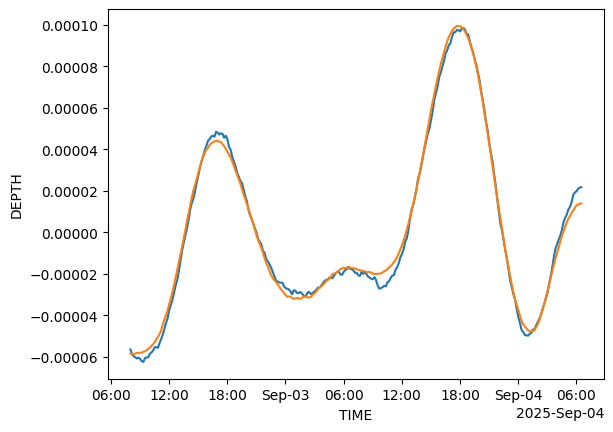

In [288]:
#TEST
i=100000
window = 300
x = ((CL[i:i+window] - CL[i:i+window].mean())/CL[i:i+window].max()).rolling(TIME=20,center=True).mean()[10:-10]
y = ((BL[i:i+window] - BL[i:i+window].mean())/BL[i:i+window].max()).rolling(TIME=20,center=True).mean()[10:-10]
x.plot()
y.plot()
correlation = signal.correlate(x, y, mode="full")
lags = signal.correlation_lags(x.size, y.size, mode="full")
lag = lags[np.argmax(correlation)]
print("delay :",lag*600,' seconds')

In [289]:
lag=np.empty(0)
window = 300
for i in np.arange(0,len(CL.TIME)-int(window/5),int(window/5)):
    x = ((CL[i:i+window] - CL[i:i+window].mean())/CL[i:i+window].max()).rolling(TIME=20,center=True).mean()[10:-10]
    y = ((BL[i:i+window] - BL[i:i+window].mean())/BL[i:i+window].max()).rolling(TIME=20,center=True).mean()[10:-10]
    correlation = signal.correlate(x, y, mode="full")
    lags = signal.correlation_lags(x.size, y.size, mode="full")
    lag=np.append(lag,lags[np.argmax(correlation)])

Text(0, 0.5, 'Phase delay estimate (seconds)')

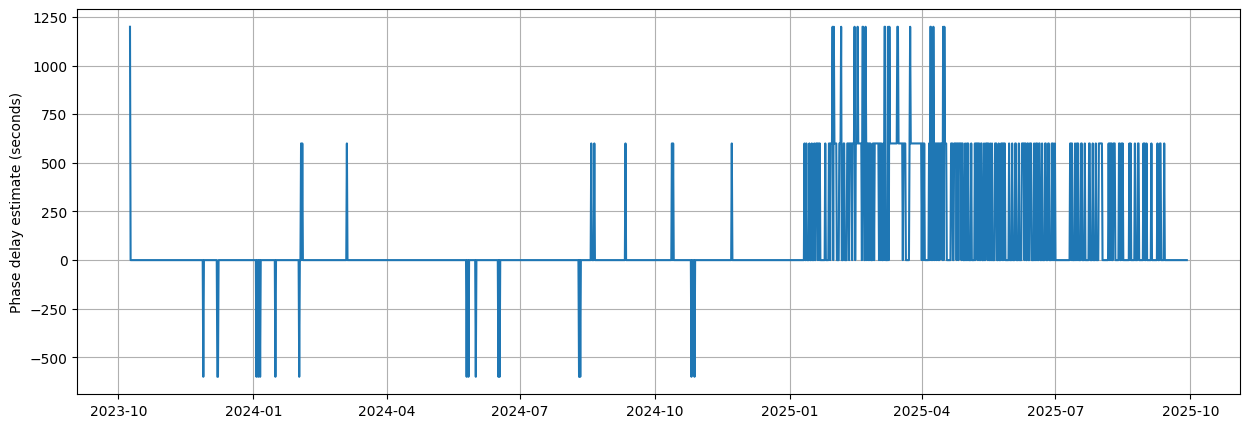

In [290]:
f,ax = plt.subplots(1,1,figsize=(15,5))
ax.plot(CL.TIME.values[0:len(AL.TIME)-int(window/5):int(window/5)],lag*600)
ax.grid()
ax.set_ylabel('Phase delay estimate (seconds)')

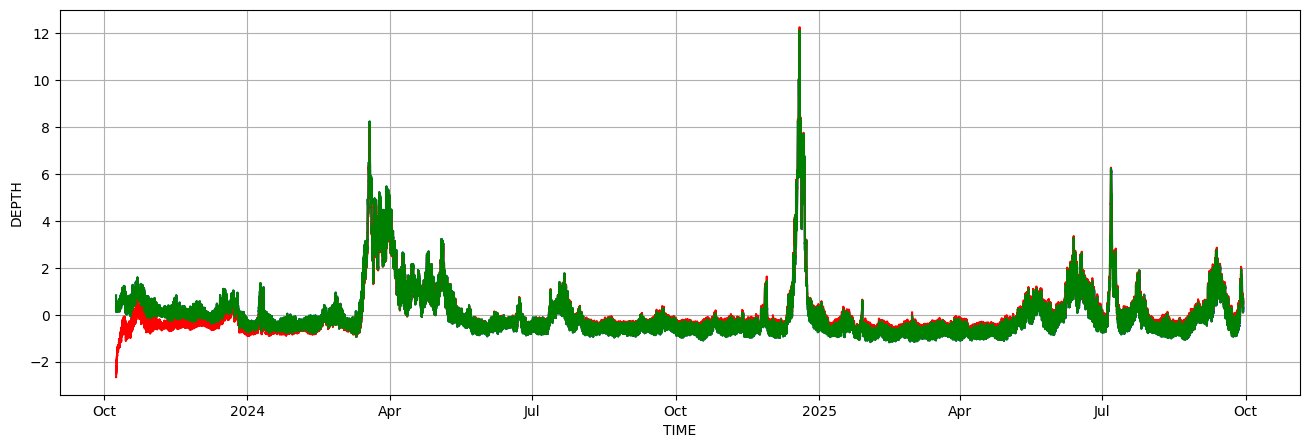

In [268]:
f,ax = plt.subplots(figsize=(16,5))
ax.grid()
A=ds1['DEPTH'].where(ds1['DEPTH_QC']<4)
(A-A.mean()).plot.line('-b',ax=ax)
B=ds2['DEPTH'].where(ds2['DEPTH_QC']<4)
(B-B.mean()).plot.line('-r',ax=ax)
C=ds3['DEPTH'].where(ds3['DEPTH_QC']<4)
(C-C.mean()).plot.line('-g',ax=ax)

In [269]:
#ds3.to_netcdf('/mnt/scale/crossroad/MOORINGS/FC4/AQD/FC4_Aquadopp_11274_corrected.nc')